# Superstore Sales Analysis

## Project Overview

This project analyzes retail sales data to identify:
- Sales trend over time
- Regional performance
- Product profitability
- Relationship between discount and profit
- Top customers

## Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn

In [47]:
import pandas as pd

df = pd.read_csv("/Sample - Superstore.csv", encoding="latin1")

print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [28]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [29]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [31]:
df["Year"] = df["Order Date"].dt.year

In [32]:
df["Month"] = df["Order Date"].dt.month

In [33]:
df[["Order Date","Year","Month"]].head()

,Order Date,Year,Month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


In [34]:
sales_year = df.groupby("Year")["Sales"].sum()
sales_year

,Sales
Year,
2014,484247.4981
2015,470532.5090
2016,609205.5980
2017,733215.2552


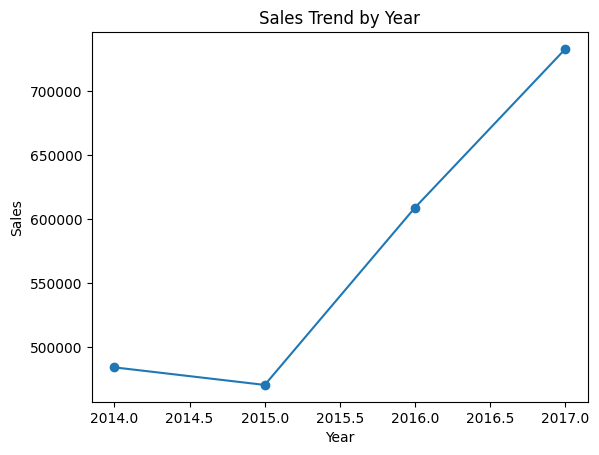

In [35]:
import matplotlib.pyplot as plt

sales_year.plot(kind="line", marker="o")

plt.title("Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [36]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


In [37]:
region_sales.sort_values(ascending=False)

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


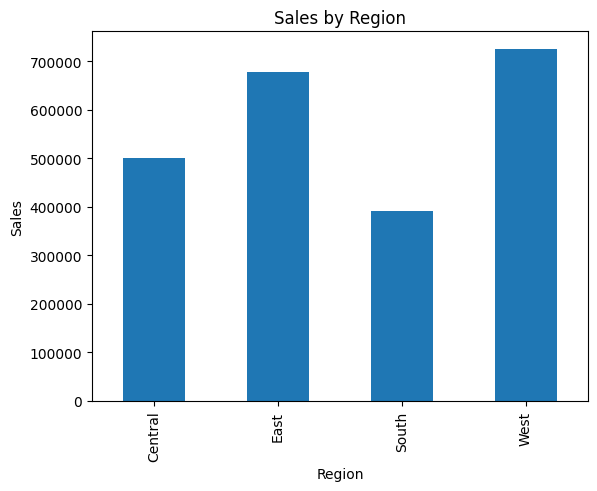

In [38]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

In [39]:
category_profit = df.groupby("Category")["Profit"].sum()
category_profit.sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


In [40]:
df[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


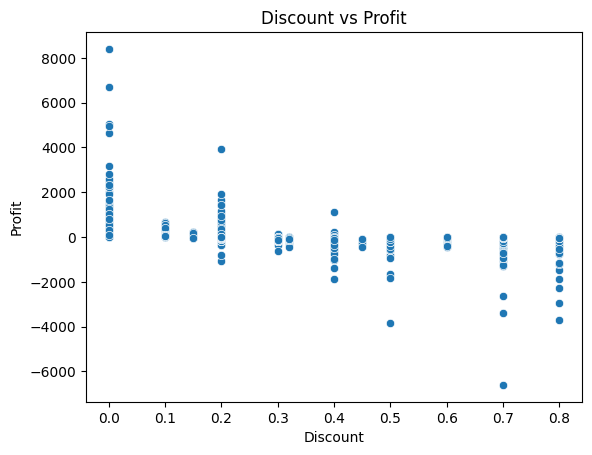

In [41]:
import seaborn as sns

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)
plt.title("Discount vs Profit")
plt.show()

In [42]:
top_customer = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customer

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


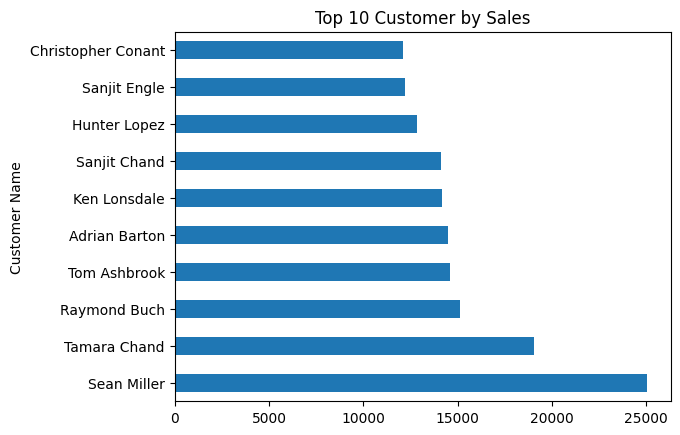

In [43]:
top_customer.plot(kind="barh")
plt.title("Top 10 Customer by Sales")
plt.show()

**Conclusion**

## Key Findings
1. Sales increased over the years, showing positive business growth.

2. The West region generated the highest total sales.

3. The Technology category achieved the highest profit.

4. Higher discounts were generally associated with lower profit.

5. A small group of customers contributed a large amount of revenue.

## Business Recommendations

- Focus marketing strategies on high-performing regions.

- Review discount policies to protect profit margins.

- Promote products in high_profit categories.

- Build customer retention strategies for top customers
